In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"C:\Users\palak\Desktop\sales project\raw data_sales.csv", encoding="latin-1")

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
# Convert Date
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [22]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [24]:
#Add columns

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month-Year'] = df['Order Date'].dt.to_period('M')

In [26]:
#Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month-Year       0
dtype: int64

In [30]:
#KPI Analysis

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

profit_margin = total_profit / total_sales

print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)
print("Profit Margin:", round(profit_margin*100,2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Profit Margin: 12.47 %


In [32]:
#Regional Analysis
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [34]:
#Category Profitability
category_profit = df.groupby('Category')['Profit'].sum()
print(category_profit)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


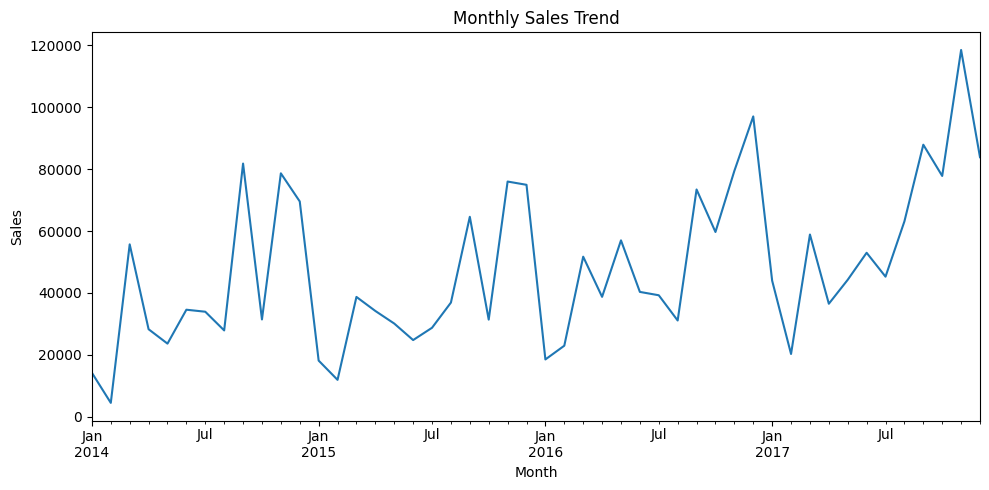

In [41]:
#Monthly Trend Analysis
monthly_sales = df.groupby('Month-Year')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [45]:
#Prepare Time Index
monthly_sales = monthly_sales.reset_index()
monthly_sales['t'] = np.arange(len(monthly_sales))

In [46]:
#Fit Linear Trend Line
coeff = np.polyfit(monthly_sales['t'], monthly_sales['Sales'], 1)
trend = np.poly1d(coeff)

In [47]:
#Forecast Next 6 Months
future_t = np.arange(len(monthly_sales), len(monthly_sales) + 6)

forecast = trend(future_t)

print("Next 6 Months Forecast:")
print(forecast)

Next 6 Months Forecast:
[69957.53579787 70859.54333018 71761.55086249 72663.55839481
 73565.56592712 74467.57345943]
